/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Precisão treino: 0.8154613466334164
Precisão teste: 0.7794612794612794


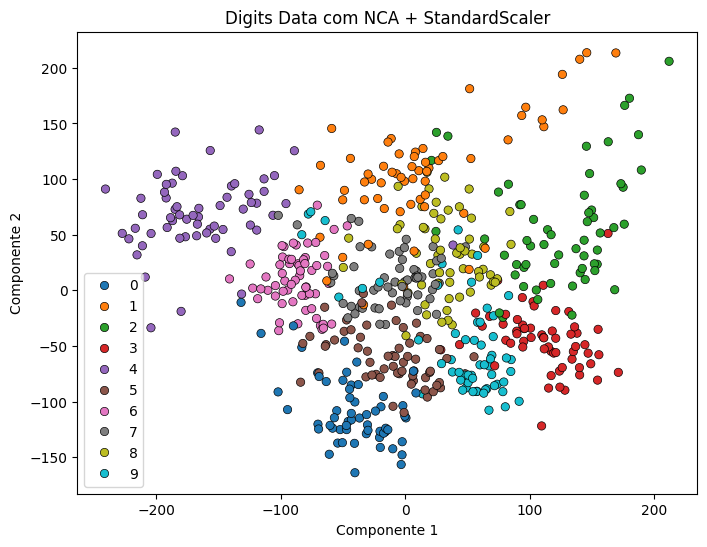

Modelo guardado.


In [5]:
# =========================================================
# TREINO
# Regressão Logística + NCA + StandardScaler
# Dataset Digits
# =========================================================

# Bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.linear_model import LogisticRegression

# =========================================================
# Dataset Digits
# =========================================================

digits = load_digits()

X = digits.data
y = digits.target

# =========================================================
# Divisão treino/teste
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.33,
    random_state=42
)

# =========================================================
# NCA + StandardScaler
# =========================================================

random_state = 42

nca = make_pipeline(
    StandardScaler(),
    NeighborhoodComponentsAnalysis(
        n_components=2,
        random_state=random_state
    ),
)

# Ajustar NCA
nca.fit(X_train, y_train)

# Transformação
X_train_nca = nca.transform(X_train)
X_test_nca = nca.transform(X_test)

# =========================================================
# LogisticRegression
# =========================================================

model = LogisticRegression(
    random_state=0,
    solver='lbfgs',
    multi_class='auto',
    max_iter=5000
)

# Treino
model.fit(X_train_nca, y_train)

# =========================================================
# Precisão
# =========================================================

print("Precisão treino:",
      model.score(X_train_nca, y_train))

print("Precisão teste:",
      model.score(X_test_nca, y_test))

# =========================================================
# Representação gráfica
# =========================================================

XX = np.c_[X_test_nca, y_test]

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=XX[:,0],
    y=XX[:,1],
    hue=y_test,
    palette='tab10',
    alpha=1.0,
    edgecolor="black",
)

plt.title("Digits Data com NCA + StandardScaler")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

plt.show()

# =========================================================
# Guardar modelo e dados
# =========================================================

joblib.dump(model, "modelo_digits.pkl")

joblib.dump((X_test_nca, y_test),
            "dados_teste.pkl")

print("Modelo guardado.")

Accuracy: 0.7794612794612794

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.85      0.88        59
           1       0.75      0.70      0.72        60
           2       0.82      0.85      0.83        59
           3       0.85      0.87      0.86        60
           4       0.95      0.97      0.96        60
           5       0.71      0.75      0.73        60
           6       0.77      0.88      0.82        60
           7       0.71      0.68      0.70        59
           8       0.60      0.57      0.58        58
           9       0.69      0.68      0.68        59

    accuracy                           0.78       594
   macro avg       0.78      0.78      0.78       594
weighted avg       0.78      0.78      0.78       594


Confusion Matrix:

[[50  0  0  0  0  6  3  0  0  0]
 [ 0 42  7  0  1  0  2  4  4  0]
 [ 0  3 50  4  0  0  0  0  2  0]
 [ 0  0  2 52  0  0  0  0  1  5]
 [ 0  0  0  0 58  0  1  0  1  0]
 [

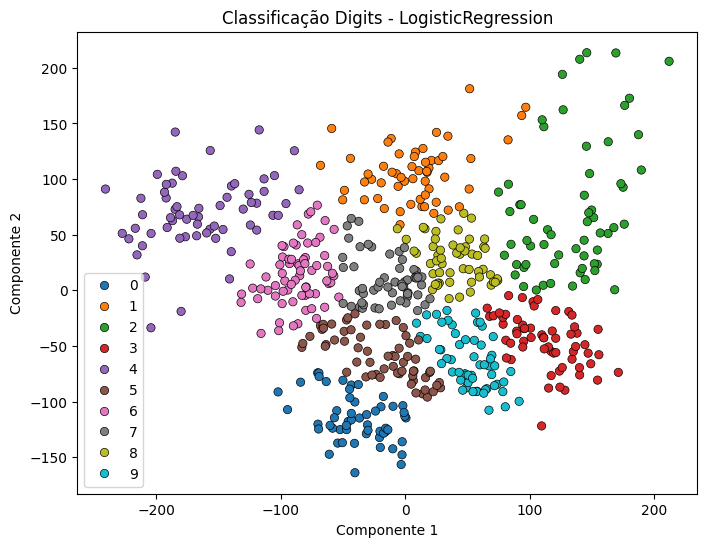

In [6]:
# =========================================================
# TESTE
# =========================================================

import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# =========================================================
# Carregar modelo e dados
# =========================================================

model = joblib.load("modelo_digits.pkl")

X_test, y_test = joblib.load("dados_teste.pkl")

# =========================================================
# Previsões
# =========================================================

prediction = model.predict(X_test)

# =========================================================
# Accuracy
# =========================================================

print("Accuracy:",
      accuracy_score(y_test, prediction))

# =========================================================
# Classification Report
# =========================================================

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    prediction
))

# =========================================================
# Confusion Matrix
# =========================================================

print("\nConfusion Matrix:\n")

print(confusion_matrix(
    y_test,
    prediction
))

# =========================================================
# Representação gráfica classificação
# =========================================================

XX = np.c_[X_test, prediction]

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=XX[:,0],
    y=XX[:,1],
    hue=prediction,
    palette='tab10',
    alpha=1.0,
    edgecolor="black",
)

plt.title("Classificação Digits - LogisticRegression")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

plt.show()

In [7]:
# =========================================================
# PREDIÇÃO
# =========================================================

import joblib

# =========================================================
# Carregar modelo
# =========================================================

model = joblib.load("modelo_digits.pkl")

X_test, y_test = joblib.load("dados_teste.pkl")

# =========================================================
# Novo dado
# =========================================================

novo_dado = X_test[0].reshape(1,-1)

# =========================================================
# Predição
# =========================================================

predicao = model.predict(novo_dado)

print("Classe prevista:", predicao[0])

print("Classe real:", y_test[0])

Classe prevista: 6
Classe real: 6
